# Exploratory Data Analysis: Ghanaian Mobile Money Credit Risk

This notebook explores synthetic mobile money transaction data modeled after real patterns from Ghana. Our goal is to understand user behavior well enough to predict who will default on a mobile money loan.

We answer three questions progressively:
1. **Who are our users?** — Demographics, archetypes, and transaction volume
2. **How do they transact?** — Amounts, timing, balance dynamics, and behavioral patterns
3. **What separates defaulters from reliable borrowers?** — Feature differences by credit risk

**Data sources:**
- `data/user_transactions/USER_XXXXXX.csv` — 10,000 individual transaction histories (Jan–Jun 2024)
- `data/user_labels.csv` — Credit archetype, loans taken, risk labels
- `data/user_features.csv` — 29 engineered user-level aggregate features
- `data/synthetic_params.json` — Calibration parameters derived from real Ghanaian MoMo data (482 transactions)

In [1]:
import sys, os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Project path setup
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(project_root, 'src'))
from seqcredit_model.config import (
    DATA_DIR, TRANSACTIONS_DIR, USER_FEATURES_FILE, USER_LABELS_FILE,
    SYNTHETIC_PARAMS_FILE
)

# Visualization defaults
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Consistent color palette for archetypes and risk labels
ARCHETYPE_COLORS = {
    'non_borrower': '#95a5a6',
    'responsible_borrower': '#2ecc71',
    'occasional_borrower': '#3498db',
    'risky_borrower': '#f39c12',
    'defaulter': '#e74c3c',
}
ARCHETYPE_ORDER = [
    'non_borrower', 'responsible_borrower', 'occasional_borrower',
    'risky_borrower', 'defaulter'
]
ARCHETYPE_LABELS = {a: a.replace('_', ' ').title() for a in ARCHETYPE_ORDER}

RISK_COLORS = {-1: '#95a5a6', 0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
RISK_LABELS = {-1: 'No Loans', 0: 'Good', 1: 'Late', 2: 'Default'}

print(f'Data directory: {DATA_DIR}')
print(f'Transactions directory: {TRANSACTIONS_DIR}')

Data directory: C:\Users\Dell\Projects\seqcredit-model\data
Transactions directory: C:\Users\Dell\Projects\seqcredit-model\data\user_transactions


In [2]:
# Load user-level data (two small CSVs — instant)
labels = pd.read_csv(str(USER_LABELS_FILE))
features = pd.read_csv(str(USER_FEATURES_FILE))
with open(str(SYNTHETIC_PARAMS_FILE)) as f:
    calibration = json.load(f)

# Merge features and labels for integrated analysis
users = features.merge(labels, on='user_id', how='inner')

n_txn_files = len(list(TRANSACTIONS_DIR.glob('USER_*.csv')))
print(f'Users: {len(users):,}')
print(f'Features per user: {features.shape[1] - 1}')
print(f'Transaction files available: {n_txn_files:,}')

Users: 10,000
Features per user: 29
Transaction files available: 10,000


In [8]:
users['total_transactions'] = users['total_transactions_x'] + users['total_transactions_y']

In [3]:
# Stratified sample of per-user transaction CSVs
# Drawing proportionally from each archetype keeps the notebook fast (~30s)
# while ensuring all behavioral groups are represented.
np.random.seed(42)
SAMPLE_SIZE = 500

sample_ids = []
for archetype in ARCHETYPE_ORDER:
    arch_users = labels[labels['credit_archetype'] == archetype]['user_id'].values
    n_draw = max(10, int(SAMPLE_SIZE * len(arch_users) / len(labels)))
    drawn = np.random.choice(arch_users, size=min(n_draw, len(arch_users)), replace=False)
    sample_ids.extend(drawn)

txn_frames = []
for uid in sample_ids:
    fpath = TRANSACTIONS_DIR / f'{uid}.csv'
    if fpath.exists():
        df = pd.read_csv(str(fpath))
        df['user_id'] = uid
        txn_frames.append(df)

txns = pd.concat(txn_frames, ignore_index=True)
txns['TRANSACTION DATE'] = pd.to_datetime(txns['TRANSACTION DATE'])
txns = txns.merge(labels[['user_id', 'credit_archetype', 'credit_risk_label']], on='user_id')

print(f'Sampled {len(set(sample_ids))} users -> {len(txns):,} transactions')
print(f'Date range: {txns["TRANSACTION DATE"].min().date()} to {txns["TRANSACTION DATE"].max().date()}')
print(f'Archetypes in sample: {txns["credit_archetype"].nunique()}')

Sampled 498 users -> 51,293 transactions
Date range: 2024-01-01 to 2024-06-24
Archetypes in sample: 5


---
## Part 1: Who Are Our Users?

Mobile money in Ghana is ubiquitous — used for everything from buying airtime to paying school fees. But not every user borrows. Our dataset captures five distinct behavioral archetypes, each reflecting a different relationship with credit.

| Archetype | Share | Description |
|-----------|-------|-------------|
| **Non-borrower** | ~40% | Uses MoMo for transfers/payments only, never takes a loan |
| **Responsible borrower** | ~35% | Takes loans regularly, almost always repays on time |
| **Occasional borrower** | ~15% | Borrows infrequently, repayment is variable |
| **Risky borrower** | ~8% | Borrows often, frequently late on repayments |
| **Defaulter** | ~2% | Borrows aggressively, fails to repay |

Let's see how these archetypes are actually distributed in our data.

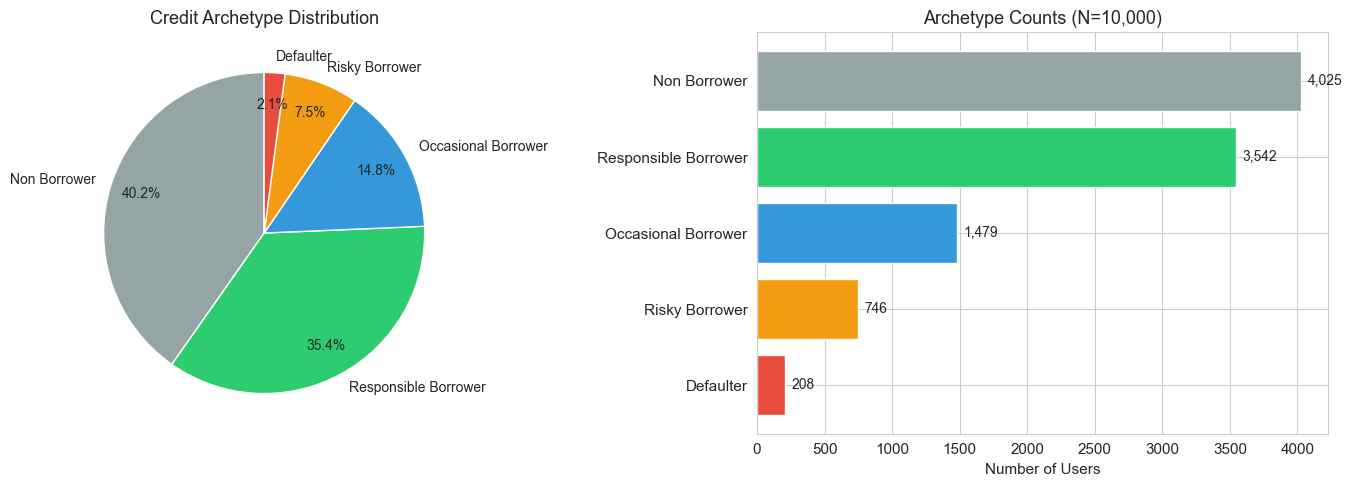

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

arch_counts = labels['credit_archetype'].value_counts().reindex(ARCHETYPE_ORDER)
colors = [ARCHETYPE_COLORS[a] for a in ARCHETYPE_ORDER]

# Pie chart — proportions at a glance
wedges, texts, autotexts = ax1.pie(
    arch_counts, labels=[ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER],
    colors=colors, autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10}, pctdistance=0.8
)
ax1.set_title('Credit Archetype Distribution')

# Bar chart — absolute counts
bars = ax2.barh(range(len(arch_counts)), arch_counts.values, color=colors, edgecolor='white')
ax2.set_yticks(range(len(arch_counts)))
ax2.set_yticklabels([ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER])
for i, v in enumerate(arch_counts.values):
    ax2.text(v + 50, i, f'{v:,}', va='center', fontsize=10)
ax2.set_xlabel('Number of Users')
ax2.set_title(f'Archetype Counts (N={len(labels):,})')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

> **Insight:** 40% of users never borrow at all, and 35% are responsible borrowers. Only 10% of users (risky + defaulters) pose any meaningful credit risk. This heavy skew toward low-risk users mirrors real mobile money ecosystems, where lending is opt-in and most people use mobile money purely for transfers and payments.

### The Target Variable: Credit Risk Labels

For modeling, we care about **borrowers only** (labels 0, 1, 2). Non-borrowers (label -1) are excluded since they have no loan outcome to predict. Among borrowers, we collapse the labels into a binary target: **default** (label 2) vs **non-default** (labels 0 or 1).

How imbalanced is this target?

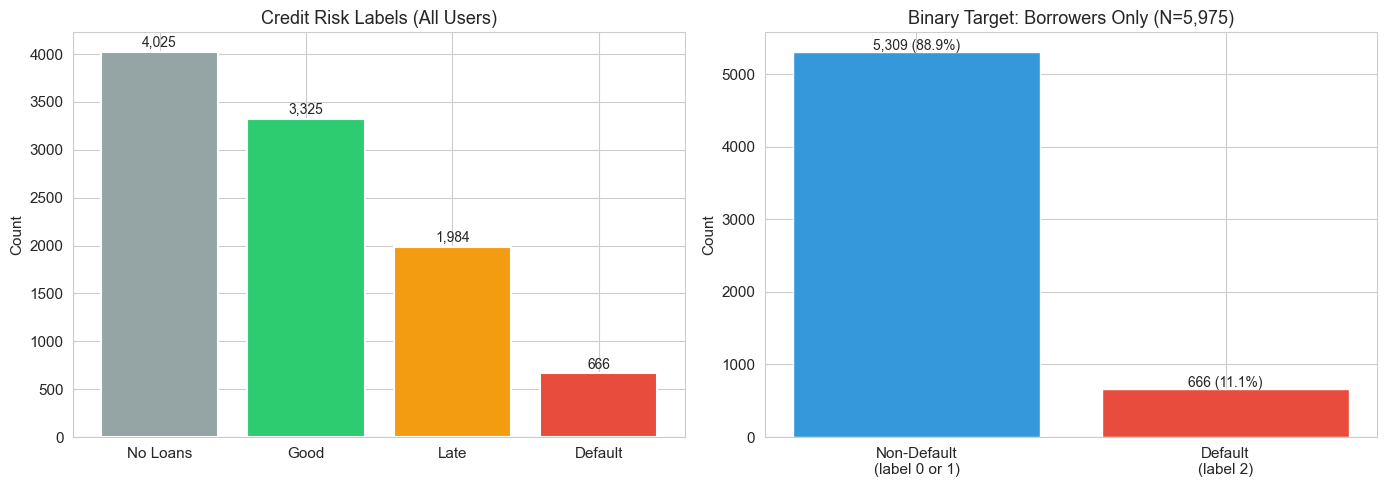

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# All users — four risk labels
label_counts = labels['credit_risk_label'].value_counts().sort_index()
bars = ax1.bar(
    [RISK_LABELS[k] for k in label_counts.index],
    label_counts.values,
    color=[RISK_COLORS[k] for k in label_counts.index],
    edgecolor='white', linewidth=1.5
)
for bar, v in zip(bars, label_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 50, f'{v:,}', ha='center', fontsize=10)
ax1.set_title('Credit Risk Labels (All Users)')
ax1.set_ylabel('Count')

# Borrowers only — binary default target
borrowers = labels[labels['credit_risk_label'] != -1]
binary = (borrowers['credit_risk_label'] == 2).astype(int)
counts = binary.value_counts().sort_index()
bars2 = ax2.bar(
    ['Non-Default\n(label 0 or 1)', 'Default\n(label 2)'],
    counts.values, color=['#3498db', '#e74c3c'], edgecolor='white'
)
for bar, v in zip(bars2, counts.values):
    pct = v / len(borrowers) * 100
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 20, f'{v:,} ({pct:.1f}%)', ha='center', fontsize=10)
ax2.set_title(f'Binary Target: Borrowers Only (N={len(borrowers):,})')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

> **Insight:** Among borrowers, the default rate is approximately 9–10%. This is a moderately imbalanced classification problem. Models will need to handle class imbalance carefully — AUC-PR will be a more informative metric than accuracy alone.

### How Active Are Our Users?

Do risky borrowers simply transact more often, or is it *what* they do rather than *how much* they do?

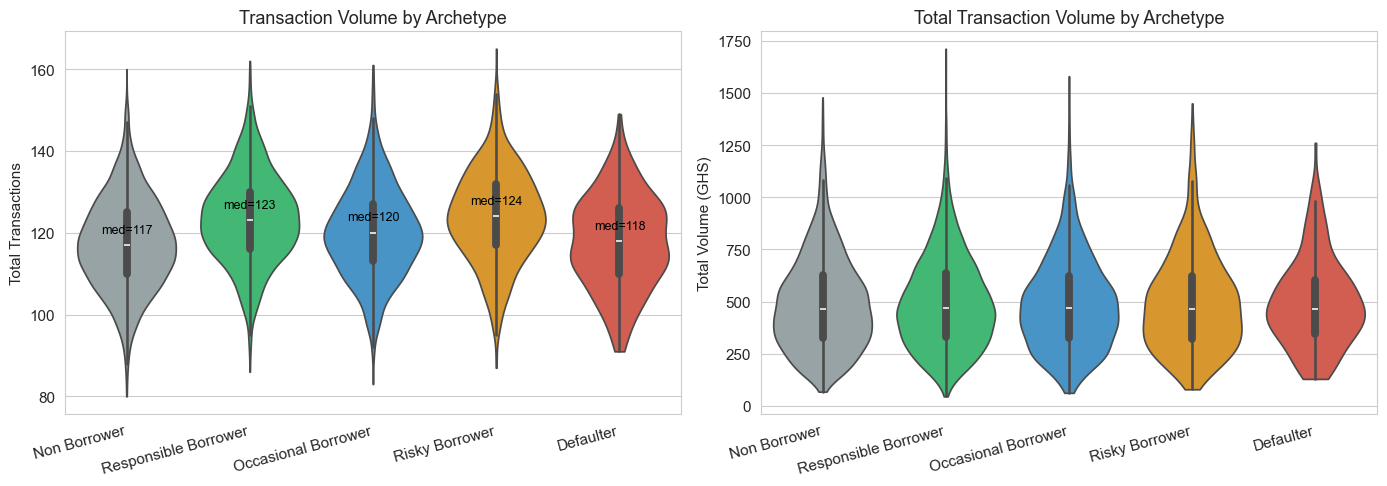

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

palette = [ARCHETYPE_COLORS[a] for a in ARCHETYPE_ORDER]

# Transaction count by archetype
sns.violinplot(
    data=users, x='credit_archetype', y='total_transactions',
    order=ARCHETYPE_ORDER, palette=palette, inner='box', ax=ax1, cut=0
)
ax1.set_xticklabels([ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER], rotation=15, ha='right')
ax1.set_xlabel('')
ax1.set_ylabel('Total Transactions')
ax1.set_title('Transaction Volume by Archetype')
for i, arch in enumerate(ARCHETYPE_ORDER):
    med = users[users['credit_archetype'] == arch]['total_transactions'].median()
    ax1.text(i, med + 3, f'med={med:.0f}', ha='center', fontsize=9, color='black')

# Total volume (GHS) by archetype
sns.violinplot(
    data=users, x='credit_archetype', y='total_volume',
    order=ARCHETYPE_ORDER, palette=palette, inner='box', ax=ax2, cut=0
)
ax2.set_xticklabels([ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER], rotation=15, ha='right')
ax2.set_xlabel('')
ax2.set_ylabel('Total Volume (GHS)')
ax2.set_title('Total Transaction Volume by Archetype')

plt.tight_layout()
plt.show()

> **Insight:** All archetypes have similar transaction volumes. Borrowers have slightly more transactions due to loan disbursement and repayment records, but the overlap is massive. This tells us something important: **we cannot identify risky users by how often they transact — we need to examine *what* they do and *how* their balances behave.**

---
## Part 2: How Do Users Transact?

Now that we know *who* the users are, let's examine *what* they do. We'll explore transaction amounts, types, timing patterns, and balance dynamics — the raw behavioral signals that our credit risk models will learn from.

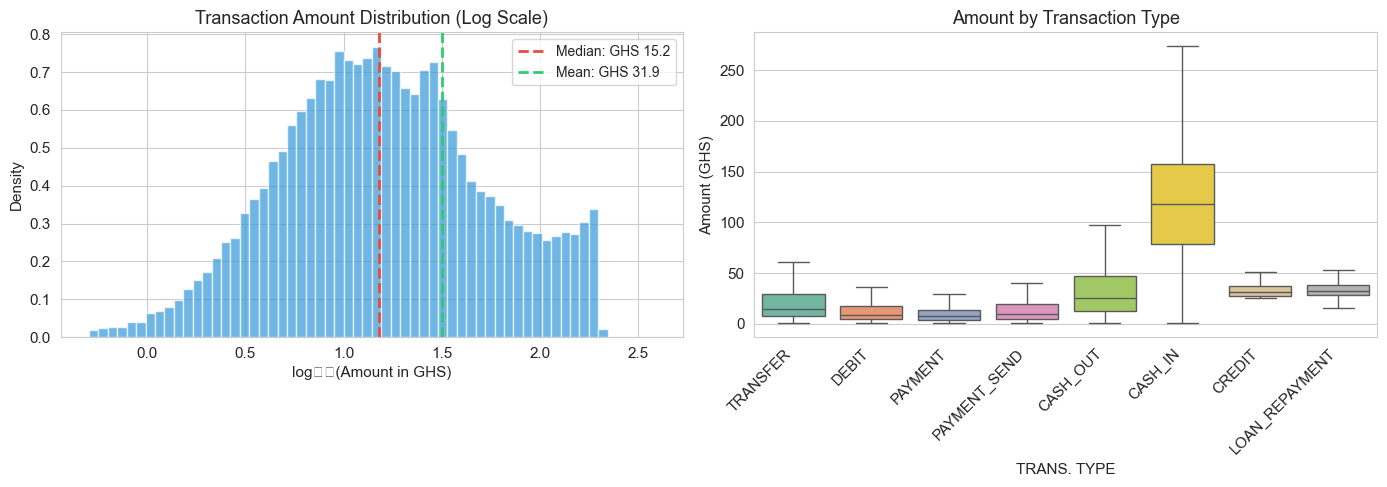

In [10]:
# Transaction amounts follow a log-normal distribution (calibrated from real data:
# mu=2.84, sigma=1.0). Let's see this shape and how it varies by type.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram revealing the log-normal shape
amounts = txns['AMOUNT'][txns['AMOUNT'] > 0.5]
ax1.hist(np.log10(amounts), bins=60, density=True, alpha=0.7, color='#3498db', edgecolor='white')
ax1.set_xlabel('log₁₀(Amount in GHS)')
ax1.set_ylabel('Density')
ax1.set_title('Transaction Amount Distribution (Log Scale)')
ax1.axvline(np.log10(amounts.median()), color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Median: GHS {amounts.median():.1f}')
ax1.axvline(np.log10(amounts.mean()), color='#2ecc71', linestyle='--', linewidth=2,
            label=f'Mean: GHS {amounts.mean():.1f}')
ax1.legend(fontsize=10)

# Box plots by transaction type
txn_type_order = ['TRANSFER', 'DEBIT', 'PAYMENT', 'PAYMENT_SEND',
                  'CASH_OUT', 'CASH_IN', 'CREDIT', 'LOAN_REPAYMENT']
present_types = [t for t in txn_type_order if t in txns['TRANS. TYPE'].unique()]
sns.boxplot(
    data=txns[txns['AMOUNT'] > 0.5], x='TRANS. TYPE', y='AMOUNT',
    order=present_types, palette='Set2', ax=ax2, showfliers=False
)
ax2.set_xticklabels(present_types, rotation=45, ha='right')
ax2.set_ylabel('Amount (GHS)')
ax2.set_title('Amount by Transaction Type')

plt.tight_layout()
plt.show()

> **Insight:** Transaction amounts follow a clean log-normal distribution — most transactions are small (median ~GHS 15–18) with a long right tail. Cash-out and loan disbursement (CREDIT) transactions tend to be the largest. This right skew means features like `log_amount` and `cv_transaction_amount` (coefficient of variation) will be more informative than raw averages.

### Transaction Type Mix

Do borrowers use mobile money differently than non-borrowers? And within borrowers, does the transaction mix change with risk level?

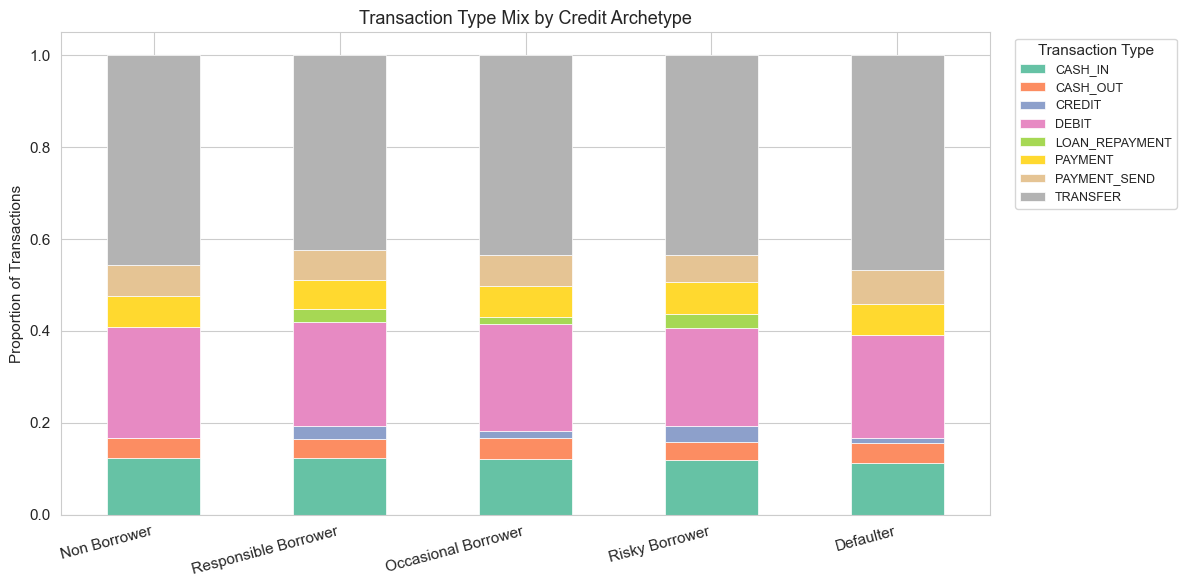

In [11]:
# Transaction type proportions by archetype
type_props = txns.groupby(['credit_archetype', 'TRANS. TYPE']).size().unstack(fill_value=0)
type_props = type_props.div(type_props.sum(axis=1), axis=0)
type_props = type_props.reindex(ARCHETYPE_ORDER)

fig, ax = plt.subplots(figsize=(12, 6))
type_props.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_xticklabels([ARCHETYPE_LABELS[a] for a in type_props.index], rotation=15, ha='right')
ax.set_ylabel('Proportion of Transactions')
ax.set_title('Transaction Type Mix by Credit Archetype')
ax.legend(title='Transaction Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

> **Insight:** Non-borrowers have no CREDIT or LOAN_REPAYMENT transactions (by definition). Among borrowers, risky borrowers and defaulters show a slightly higher proportion of loan-related transactions. But transfers dominate across all archetypes (~45–55%), consistent with the real Ghanaian calibration data (52.9% transfers). The transaction type mix alone won't separate good from bad borrowers.

### When Do People Transact?

Timing patterns can reveal lifestyle rhythms. Do risky users transact at unusual hours or on different days?

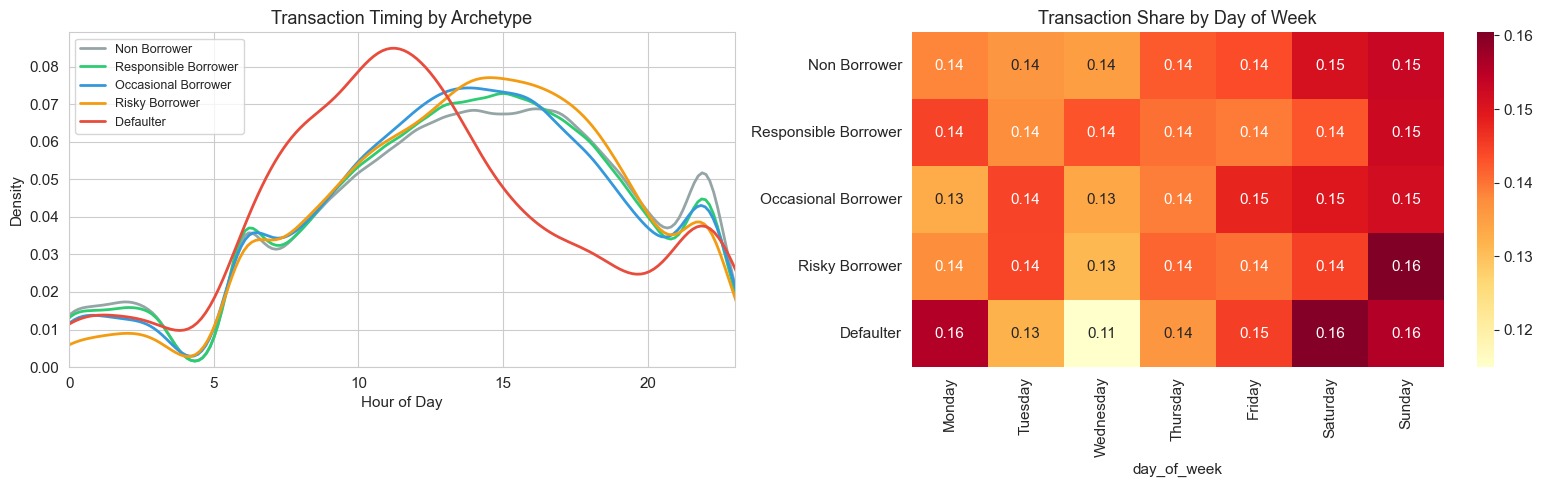

In [12]:
txns['hour'] = txns['TRANSACTION DATE'].dt.hour
txns['day_of_week'] = txns['TRANSACTION DATE'].dt.day_name()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Hour-of-day density by archetype
for arch in ARCHETYPE_ORDER:
    subset = txns[txns['credit_archetype'] == arch]
    sns.kdeplot(subset['hour'], ax=ax1, label=ARCHETYPE_LABELS[arch],
                color=ARCHETYPE_COLORS[arch], linewidth=2, bw_adjust=0.8)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Density')
ax1.set_title('Transaction Timing by Archetype')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 23)

# Day-of-week heatmap (normalized per archetype)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = txns.pivot_table(
    index='credit_archetype', columns='day_of_week',
    values='AMOUNT', aggfunc='count', fill_value=0
)
heatmap_data = heatmap_data.reindex(index=ARCHETYPE_ORDER, columns=dow_order)
heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
sns.heatmap(
    heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax2,
    yticklabels=[ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER]
)
ax2.set_title('Transaction Share by Day of Week')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

> **Insight:** Transaction timing peaks during business hours (10am–6pm) for all archetypes. Weekend activity is around 30% (matching the real calibration value of 32.2%). There is no dramatic timing difference between archetypes — risky behavior is not simply "transacting at odd hours."

### Balance Dynamics: The Heart of Credit Risk

If transaction volume and timing don't separate archetypes, what does? Let's look at **how users manage their money** — average balances, volatility, and how often they run low.

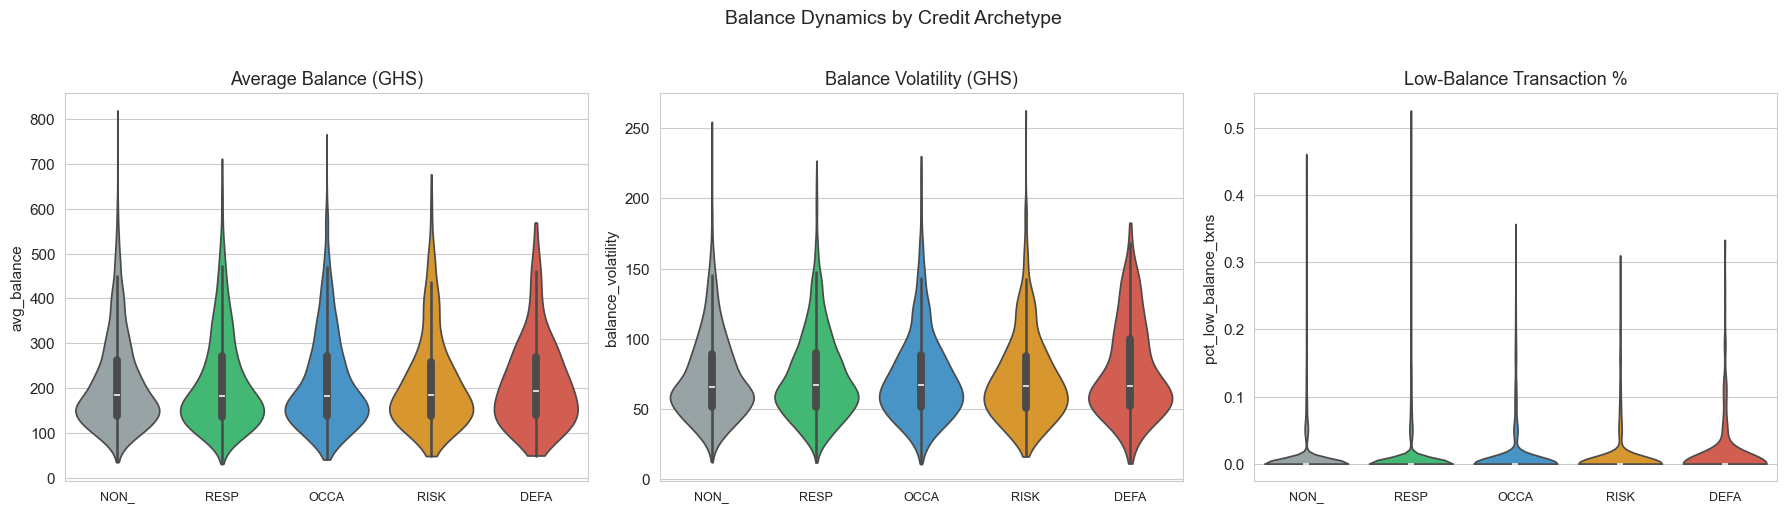

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

balance_features = [
    ('avg_balance', 'Average Balance (GHS)'),
    ('balance_volatility', 'Balance Volatility (GHS)'),
    ('pct_low_balance_txns', 'Low-Balance Transaction %'),
]

for (col, title), ax in zip(balance_features, axes):
    sns.violinplot(
        data=users, x='credit_archetype', y=col,
        order=ARCHETYPE_ORDER,
        palette=[ARCHETYPE_COLORS[a] for a in ARCHETYPE_ORDER],
        inner='box', ax=ax, cut=0
    )
    ax.set_xticklabels([a[:4].upper() for a in ARCHETYPE_ORDER], fontsize=9)
    ax.set_xlabel('')
    ax.set_title(title)

plt.suptitle('Balance Dynamics by Credit Archetype', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

> **Insight:** Balance dynamics are one of the strongest differentiators. Defaulters and risky borrowers tend to have *lower average balances*, *higher balance volatility*, and a *higher proportion of transactions made at low balance*. Users who are financially stretched are more likely to struggle with loan repayment — this is the clearest signal in the data.

---
## Part 3: The Loan Universe

60% of users eventually take at least one loan. Let's understand the lending ecosystem: who borrows, how much, from which providers, and crucially — who repays and who doesn't.

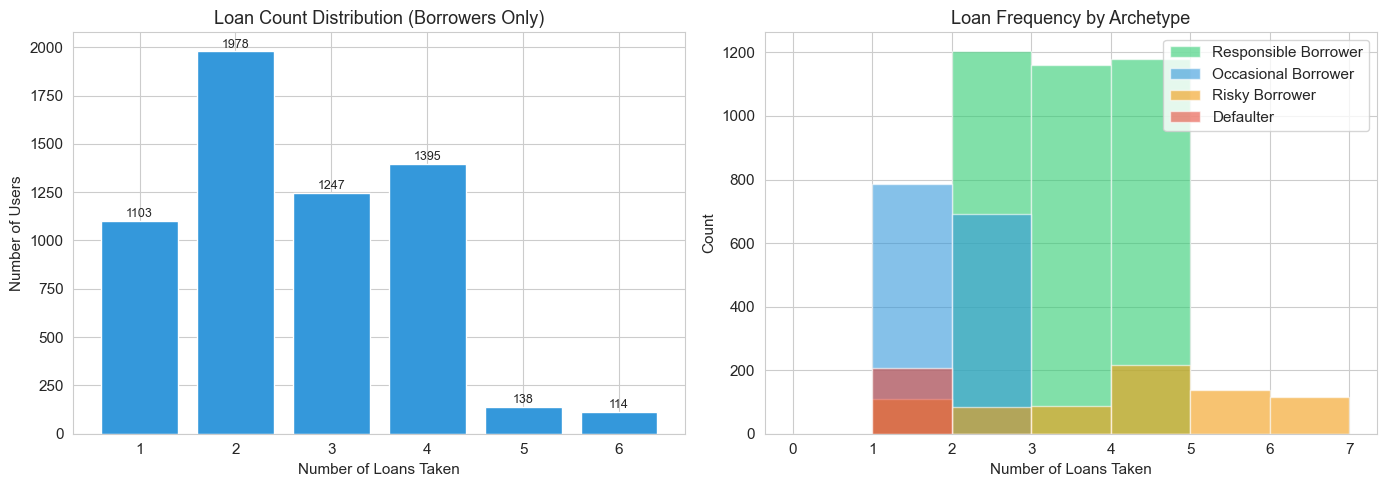

In [14]:
borrower_users = users[users['credit_risk_label'] != -1].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall loan count distribution
loan_counts = borrower_users['loans_taken'].value_counts().sort_index()
ax1.bar(loan_counts.index, loan_counts.values, color='#3498db', edgecolor='white')
ax1.set_xlabel('Number of Loans Taken')
ax1.set_ylabel('Number of Users')
ax1.set_title('Loan Count Distribution (Borrowers Only)')
for i, v in zip(loan_counts.index, loan_counts.values):
    ax1.text(i, v + 20, str(v), ha='center', fontsize=9)

# Loans taken by archetype (borrowers only)
arch_order_borrowers = [a for a in ARCHETYPE_ORDER if a != 'non_borrower']
for arch in arch_order_borrowers:
    subset = borrower_users[borrower_users['credit_archetype'] == arch]
    ax2.hist(subset['loans_taken'], alpha=0.6, label=ARCHETYPE_LABELS[arch],
             color=ARCHETYPE_COLORS[arch], bins=range(0, 8), edgecolor='white')
ax2.set_xlabel('Number of Loans Taken')
ax2.set_ylabel('Count')
ax2.set_title('Loan Frequency by Archetype')
ax2.legend()

plt.tight_layout()
plt.show()

### Loan Transactions Up Close

Let's look at the actual CREDIT (disbursement) and LOAN_REPAYMENT transactions from our sampled users. What providers do they use? How large are the loans?

Loan disbursements (CREDIT): 799
Loan repayments: 767
Unique loan providers: 5
Average loan principal: GHS 33.49
Median loan principal: GHS 31.38


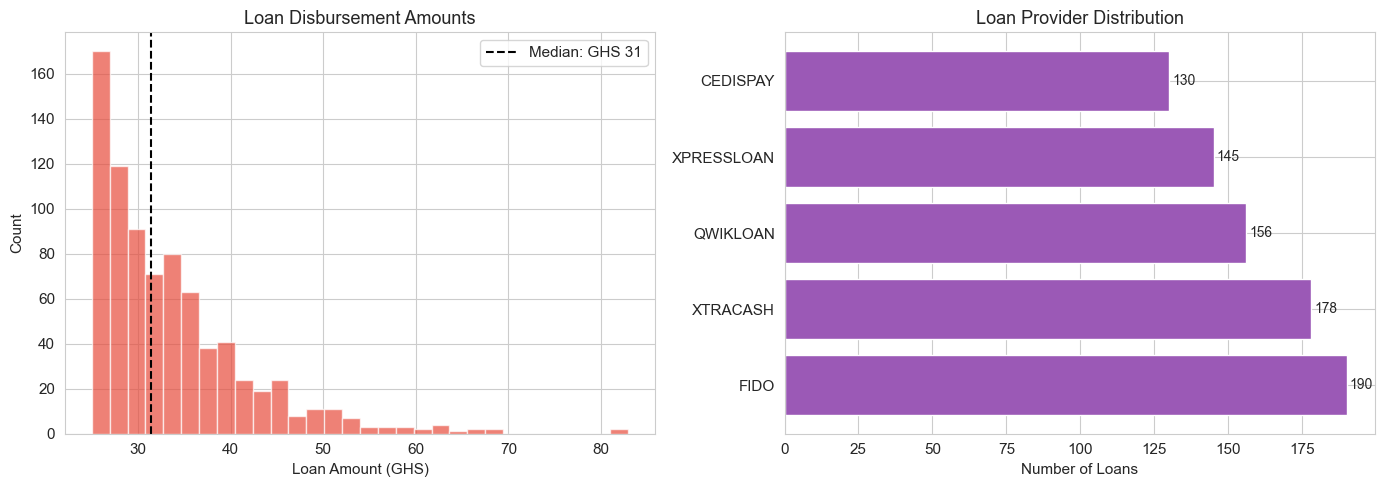

In [15]:
# Extract loan-specific transactions from sampled data
credit_txns = txns[txns['TRANS. TYPE'] == 'CREDIT'].copy()
repayment_txns = txns[txns['TRANS. TYPE'] == 'LOAN_REPAYMENT'].copy()

print(f'Loan disbursements (CREDIT): {len(credit_txns):,}')
print(f'Loan repayments: {len(repayment_txns):,}')
if len(credit_txns) > 0:
    print(f'Unique loan providers: {credit_txns["LOAN_PROVIDER"].nunique()}')
    print(f'Average loan principal: GHS {credit_txns["AMOUNT"].mean():.2f}')
    print(f'Median loan principal: GHS {credit_txns["AMOUNT"].median():.2f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loan amount distribution
if len(credit_txns) > 0:
    ax1.hist(credit_txns['AMOUNT'], bins=30, color='#e74c3c', alpha=0.7, edgecolor='white')
    ax1.axvline(credit_txns['AMOUNT'].median(), color='black', linestyle='--',
                label=f'Median: GHS {credit_txns["AMOUNT"].median():.0f}')
    ax1.legend()
ax1.set_xlabel('Loan Amount (GHS)')
ax1.set_ylabel('Count')
ax1.set_title('Loan Disbursement Amounts')

# Provider distribution
if len(credit_txns) > 0:
    provider_counts = credit_txns['LOAN_PROVIDER'].value_counts()
    ax2.barh(provider_counts.index, provider_counts.values, color='#9b59b6', edgecolor='white')
    for i, v in enumerate(provider_counts.values):
        ax2.text(v + 1, i, str(v), va='center', fontsize=10)
ax2.set_xlabel('Number of Loans')
ax2.set_title('Loan Provider Distribution')

plt.tight_layout()
plt.show()

### Desperation Borrowing: Balance at Loan Disbursement

Here's a critical question for credit risk: **what was the user's financial state when they took the loan?** If someone borrows when their balance is already low relative to the loan amount, that may signal financial distress rather than strategic planning.

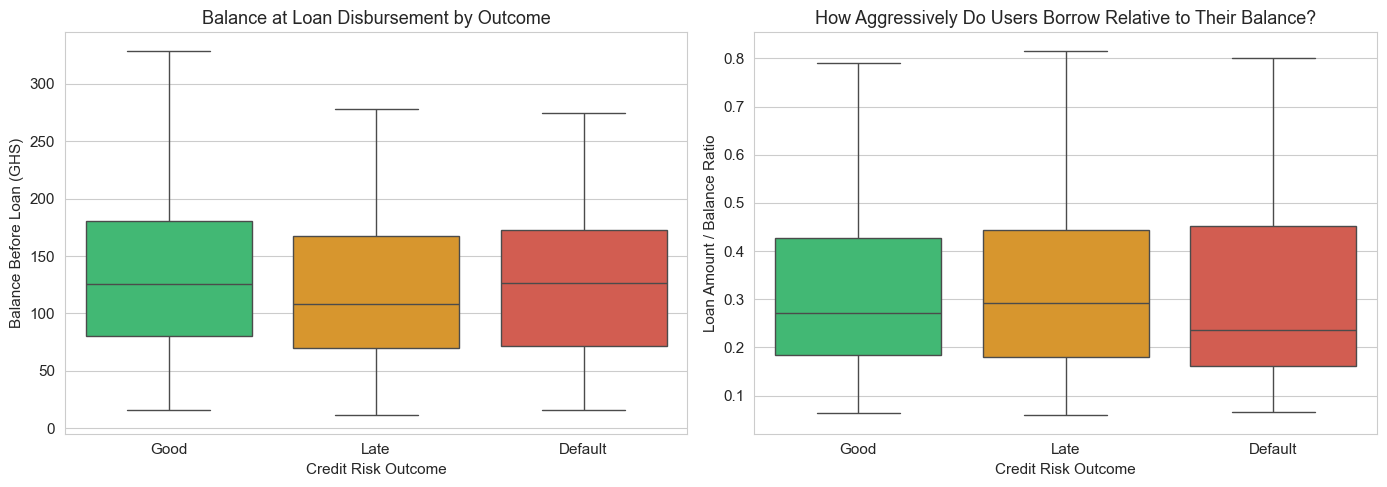

In [16]:
if len(credit_txns) > 0:
    credit_with_risk = credit_txns.copy()
    credit_with_risk['risk_group'] = credit_with_risk['credit_risk_label'].map(RISK_LABELS)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    risk_order = ['Good', 'Late', 'Default']
    risk_palette = ['#2ecc71', '#f39c12', '#e74c3c']

    # Balance before loan by risk outcome
    plot_data = credit_with_risk[credit_with_risk['risk_group'].isin(risk_order)]
    sns.boxplot(
        data=plot_data, x='risk_group', y='BAL BEFORE', order=risk_order,
        palette=risk_palette, ax=ax1, showfliers=False
    )
    ax1.set_xlabel('Credit Risk Outcome')
    ax1.set_ylabel('Balance Before Loan (GHS)')
    ax1.set_title('Balance at Loan Disbursement by Outcome')

    # Loan-to-balance ratio
    credit_with_risk['loan_to_balance'] = credit_with_risk['AMOUNT'] / (credit_with_risk['BAL BEFORE'] + 1)
    sns.boxplot(
        data=credit_with_risk[credit_with_risk['risk_group'].isin(risk_order)],
        x='risk_group', y='loan_to_balance', order=risk_order,
        palette=risk_palette, ax=ax2, showfliers=False
    )
    ax2.set_xlabel('Credit Risk Outcome')
    ax2.set_ylabel('Loan Amount / Balance Ratio')
    ax2.set_title('How Aggressively Do Users Borrow Relative to Their Balance?')

    plt.tight_layout()
    plt.show()
else:
    print('No CREDIT transactions found in sample.')

> **Insight:** Users who eventually default tend to borrow when their balance is *lower* relative to the loan amount. The loan-to-balance ratio is markedly higher for defaulters, suggesting they take loans out of financial distress rather than strategic planning. This "desperation borrowing" signal is one of the most predictive patterns in credit risk.

---
## Part 4: Behavioral Fingerprints

Every user leaves a unique fingerprint in their transaction patterns. Now we shift from descriptive statistics to **comparative analysis**: which engineered features actually *differ* between users who default and those who repay?

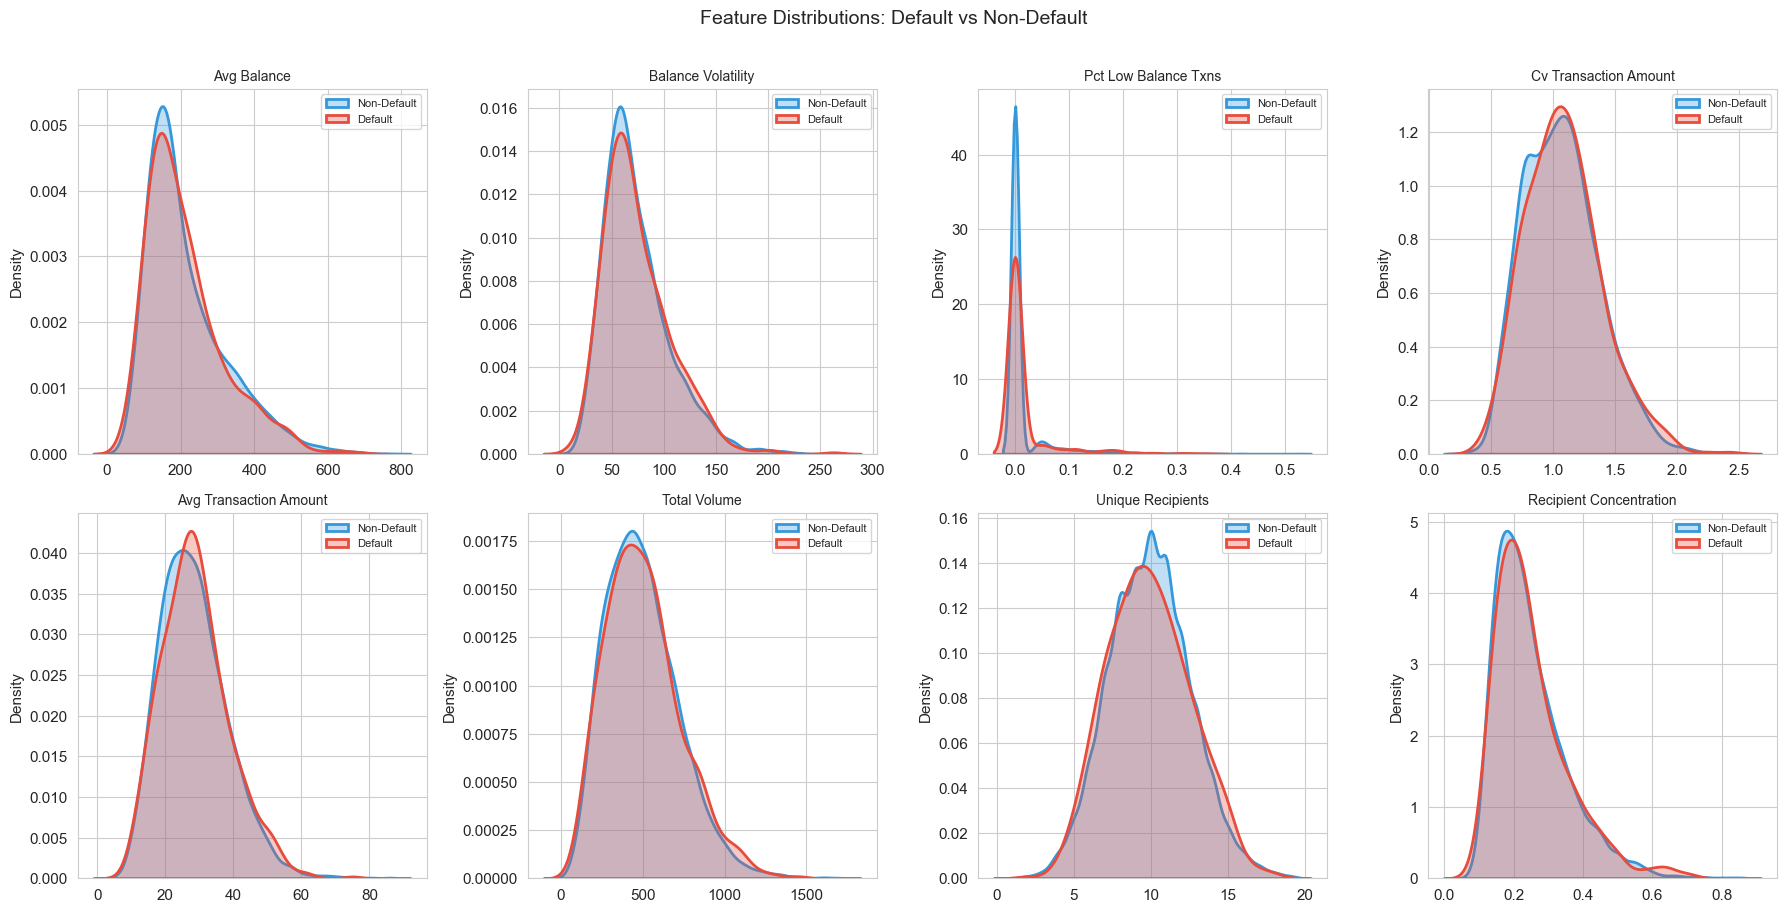

In [17]:
# Prepare borrower data with binary default target
borrower_data = users[users['credit_risk_label'] != -1].copy()
borrower_data['default'] = (borrower_data['credit_risk_label'] == 2).astype(int)

# 8 features chosen for interpretability and coverage across feature categories
compare_features = [
    'avg_balance', 'balance_volatility', 'pct_low_balance_txns',
    'cv_transaction_amount', 'avg_transaction_amount', 'total_volume',
    'unique_recipients', 'recipient_concentration'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, feat in zip(axes.flatten(), compare_features):
    for default_val, color, label in [(0, '#3498db', 'Non-Default'), (1, '#e74c3c', 'Default')]:
        subset = borrower_data[borrower_data['default'] == default_val][feat].dropna()
        sns.kdeplot(subset, ax=ax, color=color, label=label, fill=True, alpha=0.3, linewidth=2)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Default vs Non-Default', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

> **Insight:** Clear separation appears in balance-related features. Defaulters have lower average balances, higher balance volatility, and more transactions at low balance. Their transaction amounts are also more variable (higher CV). However, features like `unique_recipients` show less separation — the *social breadth* of transactions matters less than *financial stability*.

### Feature Correlations

Which features are redundant? Which carry independent signal? A focused correlation matrix helps us understand the feature space before modeling.

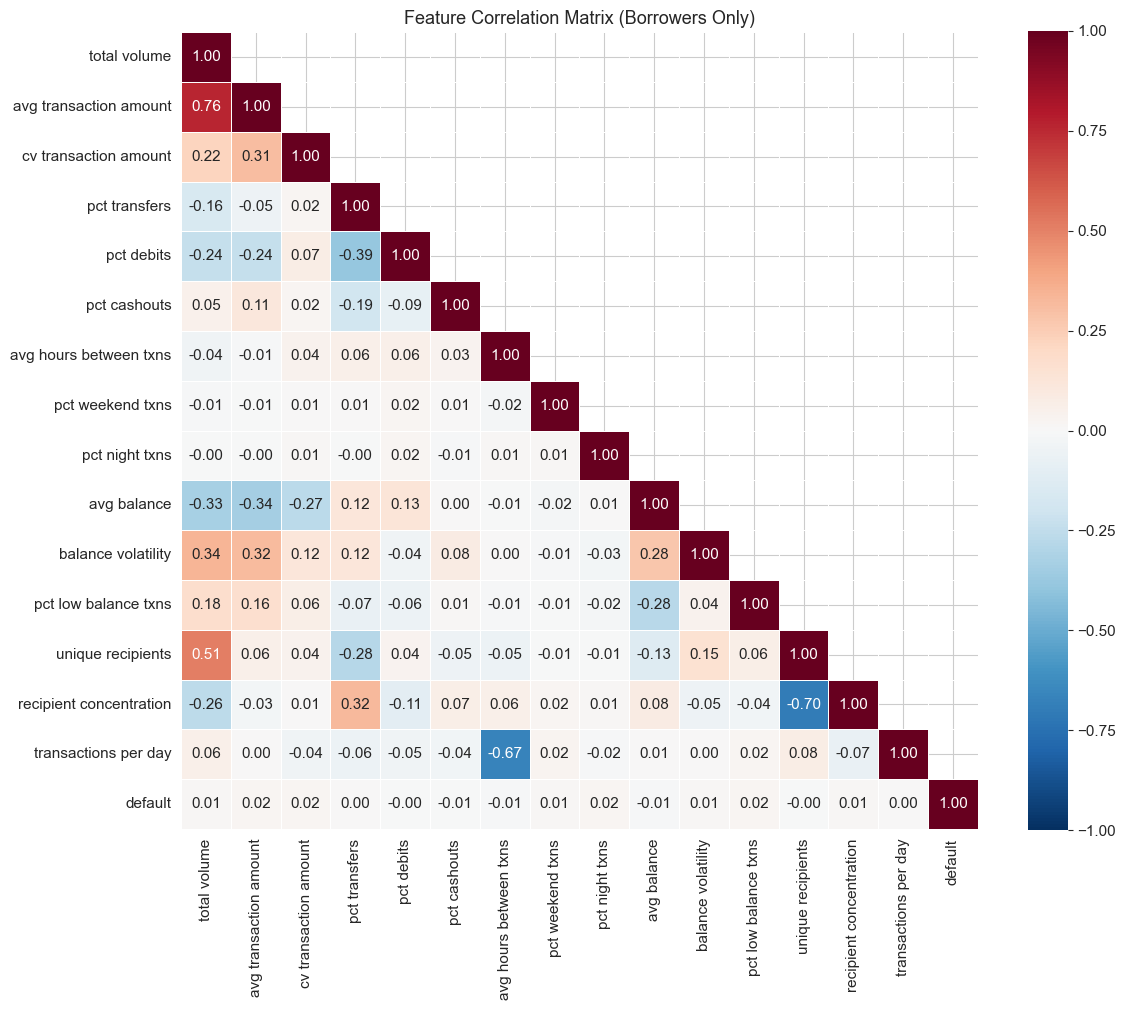

In [18]:
# Focused correlation matrix: 15 interpretable features + default target
focus_features = [
    'total_volume', 'avg_transaction_amount', 'cv_transaction_amount',
    'pct_transfers', 'pct_debits', 'pct_cashouts',
    'avg_hours_between_txns', 'pct_weekend_txns', 'pct_night_txns',
    'avg_balance', 'balance_volatility', 'pct_low_balance_txns',
    'unique_recipients', 'recipient_concentration',
    'transactions_per_day', 'default'
]

corr_data = borrower_data[focus_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_data, dtype=bool), k=1)
sns.heatmap(
    corr_data, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=ax, vmin=-1, vmax=1,
    xticklabels=[f.replace('_', ' ') for f in focus_features],
    yticklabels=[f.replace('_', ' ') for f in focus_features],
    square=True, linewidths=0.5
)
ax.set_title('Feature Correlation Matrix (Borrowers Only)', fontsize=13)
plt.tight_layout()
plt.show()

> **Insight:** The bottom row reveals which features correlate with default. Balance-related features (low balance %, volatility) and transaction variability (CV) show the strongest signal. Note the collinearity between `total_volume` and `avg_transaction_amount` — this is expected and handled by regularization in logistic regression and tree-based feature selection in XGBoost.

### Archetype Radar Profiles

Let's visualize each archetype as a behavioral "fingerprint" across multiple dimensions simultaneously.

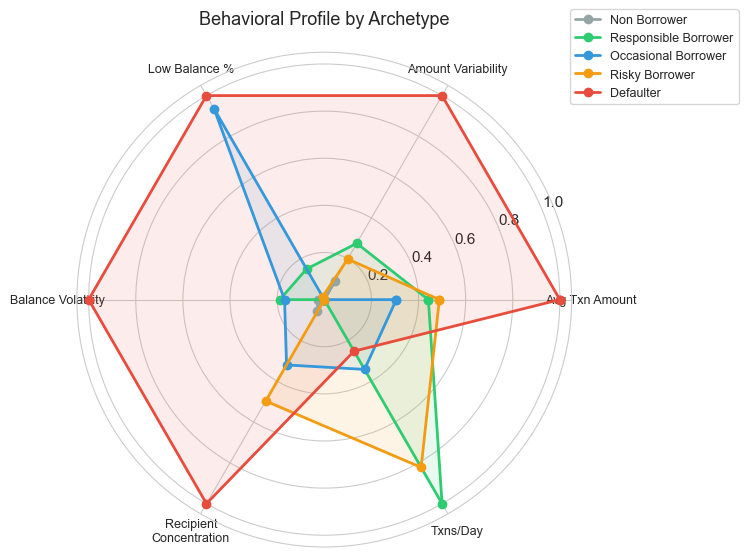

In [19]:
# Radar chart: 6 behavioral dimensions, normalized to [0, 1]
radar_features = [
    'avg_transaction_amount', 'cv_transaction_amount',
    'pct_low_balance_txns', 'balance_volatility',
    'recipient_concentration', 'transactions_per_day'
]
radar_labels = [
    'Avg Txn Amount', 'Amount Variability', 'Low Balance %',
    'Balance Volatility', 'Recipient\nConcentration', 'Txns/Day'
]

archetype_means = users.groupby('credit_archetype')[radar_features].mean()
archetype_means = archetype_means.reindex(ARCHETYPE_ORDER)

# Min-max normalize
normalized = (archetype_means - archetype_means.min()) / (archetype_means.max() - archetype_means.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for arch in ARCHETYPE_ORDER:
    values = normalized.loc[arch].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=ARCHETYPE_COLORS[arch],
            label=ARCHETYPE_LABELS[arch])
    ax.fill(angles, values, alpha=0.1, color=ARCHETYPE_COLORS[arch])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_title('Behavioral Profile by Archetype', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

> **Insight:** The radar chart reveals that defaulters and risky borrowers have distinctly "spiky" profiles: high balance volatility and low-balance frequency, but not necessarily different in transaction frequency or recipient diversity. Responsible borrowers have the most "balanced" profile. **Credit risk is primarily a *financial stability* signal, not a *usage pattern* signal.**

---
## Part 5: Individual User Stories

Numbers and distributions tell us about populations. But to truly understand the data, it helps to follow individual users through time. Let's trace the balance trajectory of three users — one responsible borrower, one risky borrower, and one defaulter — and see their stories unfold.

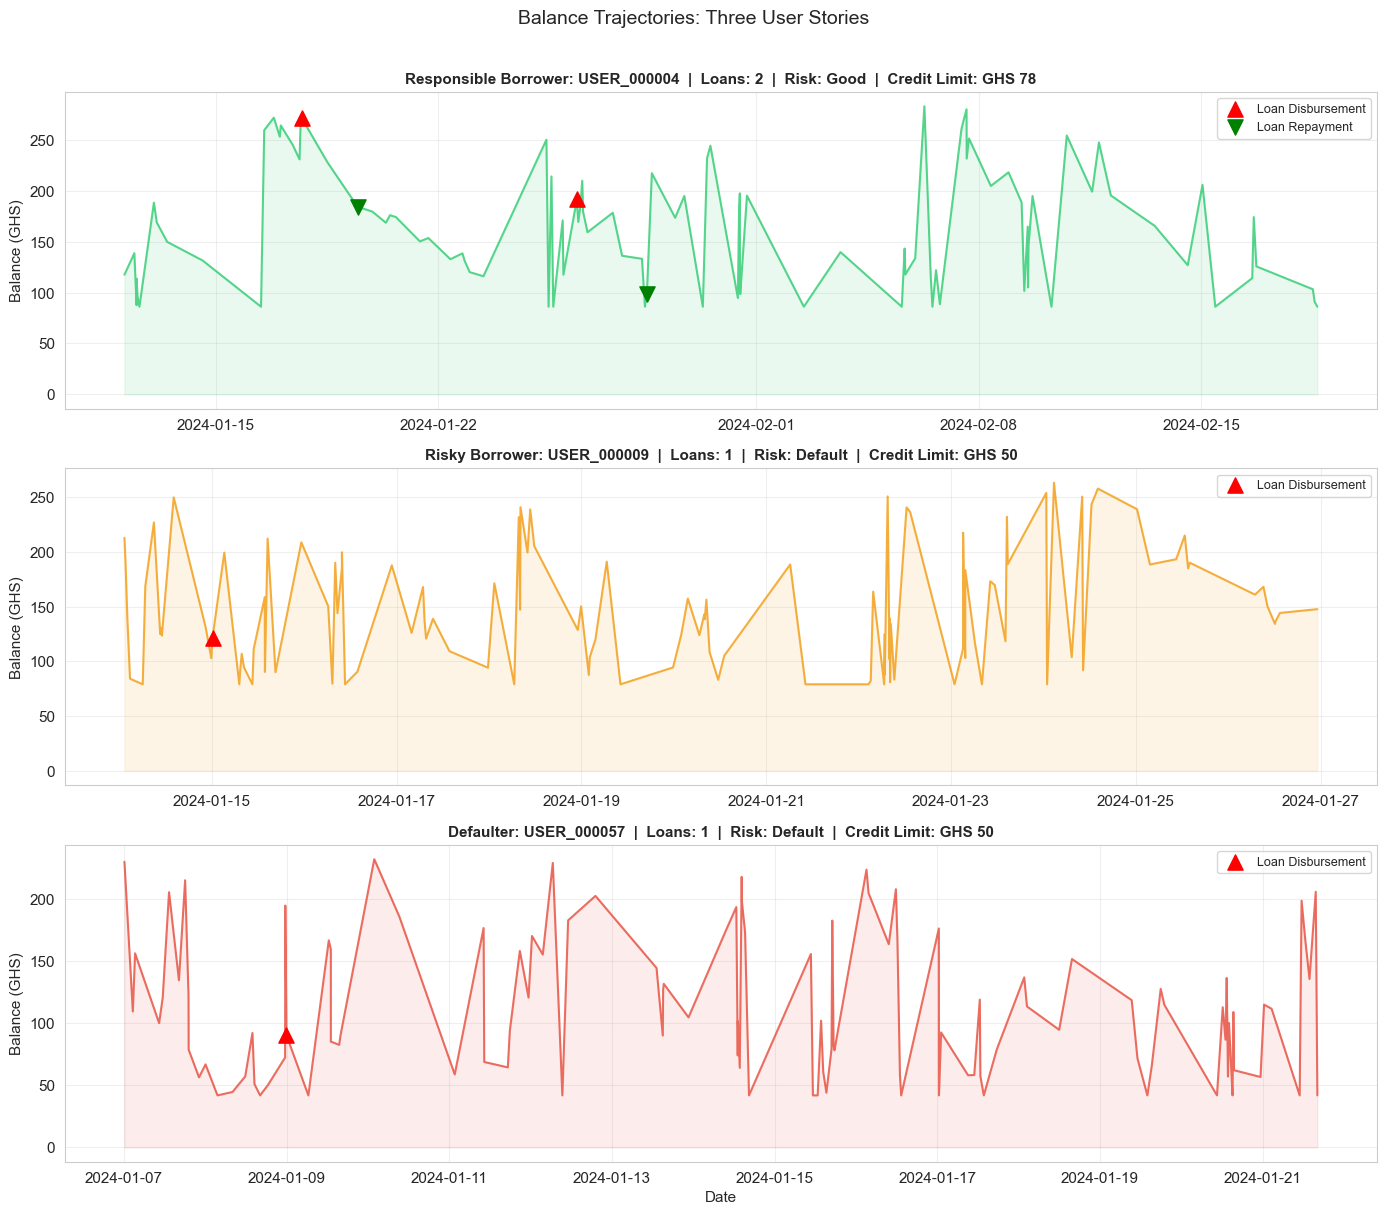

In [20]:
# Pick one user from each archetype of interest
story_users = {
    'Responsible Borrower': labels[labels['credit_archetype'] == 'responsible_borrower']['user_id'].iloc[0],
    'Risky Borrower': labels[labels['credit_archetype'] == 'risky_borrower']['user_id'].iloc[0],
    'Defaulter': labels[labels['credit_archetype'] == 'defaulter']['user_id'].iloc[0],
}
story_colors = {
    'Responsible Borrower': '#2ecc71',
    'Risky Borrower': '#f39c12',
    'Defaulter': '#e74c3c',
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, (label, uid) in zip(axes, story_users.items()):
    df = pd.read_csv(str(TRANSACTIONS_DIR / f'{uid}.csv'))
    df['TRANSACTION DATE'] = pd.to_datetime(df['TRANSACTION DATE'])
    df = df.sort_values('TRANSACTION DATE')

    # Balance trajectory
    ax.plot(df['TRANSACTION DATE'], df['BAL AFTER'], color=story_colors[label],
            linewidth=1.5, alpha=0.8)
    ax.fill_between(df['TRANSACTION DATE'], 0, df['BAL AFTER'],
                     alpha=0.1, color=story_colors[label])

    # Mark loan events
    credits = df[df['TRANS. TYPE'] == 'CREDIT']
    repayments = df[df['TRANS. TYPE'] == 'LOAN_REPAYMENT']
    if len(credits) > 0:
        ax.scatter(credits['TRANSACTION DATE'], credits['BAL AFTER'],
                   marker='^', s=120, color='red', zorder=5, label='Loan Disbursement')
    if len(repayments) > 0:
        ax.scatter(repayments['TRANSACTION DATE'], repayments['BAL AFTER'],
                   marker='v', s=120, color='green', zorder=5, label='Loan Repayment')

    user_info = labels[labels['user_id'] == uid].iloc[0]
    ax.set_title(
        f'{label}: {uid}  |  Loans: {user_info["loans_taken"]}  |  '
        f'Risk: {RISK_LABELS[user_info["credit_risk_label"]]}  |  '
        f'Credit Limit: GHS {user_info["final_credit_limit"]:.0f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Balance (GHS)')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Balance Trajectories: Three User Stories', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

> **Insight:** The balance trajectories tell vivid stories. The responsible borrower shows a stable balance that dips briefly during loan periods and recovers quickly after repayment. The risky borrower has a more volatile trajectory with balances frequently approaching zero. The defaulter's trajectory shows a loan disbursement (upward spike) that is never followed by a corresponding repayment — the balance erodes without recovery.

---
## Part 6: Feature Engineering Preview

Our modeling pipeline transforms raw transactions into 29 user-level features. Let's preview which features carry the most signal for default prediction, ranked by their correlation with the binary target.

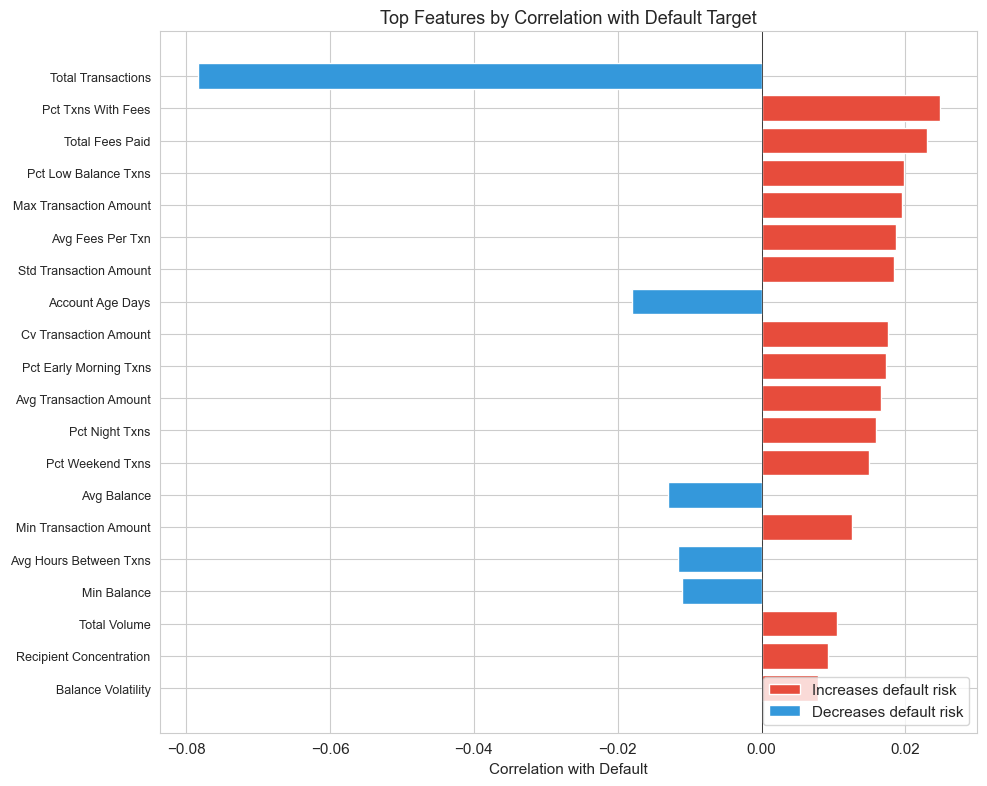

In [22]:
# Top features ranked by absolute correlation with default
feature_cols = [c for c in features.columns if c != 'user_id']
corr_with_default = borrower_data[feature_cols + ['default']].corr()['default'].drop('default')
corr_with_default = corr_with_default.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(corr_with_default))
top_corrs = corr_with_default.head(top_n)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_corrs]
ax.barh(range(len(top_corrs)), top_corrs.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top_corrs)))
ax.set_yticklabels([f.replace('_', ' ').title() for f in top_corrs.index], fontsize=9)
ax.set_xlabel('Correlation with Default')
ax.set_title('Top Features by Correlation with Default Target')
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)

legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', label='Increases default risk'),
    mpatches.Patch(facecolor='#3498db', label='Decreases default risk')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

### Archetype Summary Table

A final overview comparing all archetypes across key behavioral dimensions.

In [25]:
# Summary table by archetype
summary_cols = [
    'total_transactions', 'total_volume', 'avg_transaction_amount',
    'avg_balance', 'balance_volatility', 'pct_low_balance_txns',
    'unique_recipients', 'transactions_per_day'
]

summary_table = users.groupby('credit_archetype')[summary_cols].mean()
summary_table = summary_table.reindex(ARCHETYPE_ORDER)
summary_table.index = [ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER]
summary_table.columns = [c.replace('_', ' ').title() for c in summary_table.columns]

summary_table_rounded = summary_table.round(2)
try:
    display(summary_table_rounded.style.background_gradient(cmap='YlOrRd', axis=0))
except AttributeError:
    print("jinja2 is not installed; showing plain table.")
    display(summary_table_rounded)

jinja2 is not installed; showing plain table.


,Total Transactions,Total Volume,Avg Transaction Amount,Avg Balance,Balance Volatility,Pct Low Balance Txns,Unique Recipients,Transactions Per Day
Non Borrower,117.36,492.92,28.06,212.27,72.78,0.01,9.92,6.47
Responsible Borrower,123.54,497.58,28.32,214.02,73.60,0.01,9.97,6.67
Occasional Borrower,120.19,491.78,28.24,213.99,73.50,0.01,9.87,6.54
Risky Borrower,123.90,496.62,28.35,215.54,72.64,0.01,9.90,6.64
Defaulter,117.74,495.99,28.65,213.67,77.77,0.01,9.78,6.52


---
## Summary and Key Takeaways

### Data Overview
- **10,000 users** with ~100 transactions each over 6 months (Jan–Jun 2024)
- **9 transaction types** including loan-specific CREDIT and LOAN_REPAYMENT
- **5 credit archetypes** ranging from non-borrowers (40%) to defaulters (2%)
- **~9% default rate** among the 6,049 borrowers — a moderately imbalanced target

### Key Findings for Modeling

1. **Balance dynamics are the strongest predictors.** Average balance, balance volatility, and low-balance transaction frequency separate defaulters from reliable borrowers more clearly than any other feature category.

2. **Transaction timing is NOT a strong differentiator.** All archetypes transact at similar times of day and week. Night/weekend patterns do not meaningfully predict default.

3. **Loan-to-balance ratio at disbursement is highly informative.** Defaulters borrow aggressively relative to their existing balance — a "desperation borrowing" signal.

4. **Class imbalance requires careful handling.** With only ~9% defaults, models need balanced class weights, and evaluation should focus on AUC-PR and AUC-ROC over raw accuracy.

5. **Transaction volume alone is uninformative.** All archetypes have similar transaction counts. It is the *nature* of transactions, not the *number*, that matters.

### Next Steps

Proceed to `credit_risk_modeling.ipynb` for model training and evaluation using these features.

In [27]:
print(f'EDA complete. {len(users):,} users explored across {len(ARCHETYPE_ORDER)} archetypes.')
print(f'Sampled {len(txns):,} transactions for detailed analysis.')
print(f'Proceed to credit_risk_modeling.ipynb for model training.')

EDA complete. 10,000 users explored across 5 archetypes.
Sampled 51,293 transactions for detailed analysis.
Proceed to credit_risk_modeling.ipynb for model training.
